# BIDS EEG Data Reader

This notebook demonstrates how to load, inspect, and visualize EEG data from a BIDS (Brain Imaging Data Structure) formatted dataset using MNE-Python and MNE-BIDS libraries.

## 1. Import Required Libraries

Import necessary libraries for reading and visualizing BIDS EEG data.

In [19]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mne_icalabel import label_components

# MNE and BIDS libraries
import mne
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Set BIDS Dataset Path

Define the path to your BIDS dataset directory. This should be the root directory containing the BIDS structure with subdirectories like `sub-*/ses-*/eeg/`.

In [20]:
# Set the path to your BIDS dataset
# Update this path to point to your BIDS dataset root directory
bids_root = r"d:\Hackathons\EPFL_Life_Sciences_2026\EEG-Meditation-App\ds003969"

# Verify that the directory exists
if os.path.isdir(bids_root):
    print(f"BIDS root directory found: {bids_root}")
    print(f"Contents: {os.listdir(bids_root)}")
else:
    print(f"ERROR: BIDS root directory not found at {bids_root}")

BIDS root directory found: d:\Hackathons\EPFL_Life_Sciences_2026\EEG-Meditation-App\ds003969
Contents: ['CHANGES', 'code', 'dataset_description.json', 'participants.json', 'participants.tsv', 'README', 'sourcedata', 'sub-001']


## 3. Load BIDS Dataset Structure

Explore the BIDS dataset structure and list available subjects and sessions.

In [21]:
# Get list of subjects in the BIDS dataset
try:
    subjects = get_entity_vals(bids_root, entity_key='subject')
    print(f"Available subjects: {subjects}")
    print(f"Number of subjects: {len(subjects)}\n")
    
    # Get sessions if available
    sessions = get_entity_vals(bids_root, entity_key='session')
    if sessions:
        print(f"Available sessions: {sessions}")
        print(f"Number of sessions: {len(sessions)}\n")
    
    # Get tasks
    tasks = get_entity_vals(bids_root, entity_key='task')
    if tasks:
        print(f"Available tasks: {tasks}")
        print(f"Number of tasks: {len(tasks)}\n")
    
except Exception as e:
    print(f"Error exploring BIDS structure: {e}")

Available subjects: ['001']
Number of subjects: 1

Available tasks: ['med1breath', 'med2', 'think1', 'think2']
Number of tasks: 4



## 4. Read EEG Data Files

Load EEG data files using `read_raw_bids()` function. This example reads the first subject's EEG data.

In [25]:
# Read EEG data for the first subject
try:
    if subjects:
        # Create a BIDS path for the first subject
        subject = subjects[0]
        session = sessions[0] if sessions else None
        task = tasks[0] if tasks else None
        
        bids_path = BIDSPath(
            subject=subject,
            session=session,
            task=task,
            datatype='eeg',
            root=bids_root
        )
        
        print(f"Reading BIDS file: {bids_path}")
        
        # Read the raw EEG data
        # TODO select middle 5 min of data
        raw = read_raw_bids(bids_path=bids_path, verbose=False)

        montage = mne.channels.make_standard_montage('biosemi64')
        raw.set_montage(montage, on_missing='ignore')

        print(f"✓ Successfully loaded EEG data!")
        print(f"Data shape: {raw.get_data().shape}")
        
    else:
        print("No subjects found in the BIDS dataset!")
        raw = None
        
except Exception as e:
    print(f"Error reading EEG data: {e}")
    raw = None

Reading BIDS file: d:/Hackathons/EPFL_Life_Sciences_2026/EEG-Meditation-App/ds003969/sub-001/eeg/sub-001_task-med1breath_eeg.bdf
✓ Successfully loaded EEG data!


C:\Users\horvt\AppData\Local\Temp\ipykernel_7768\754302691.py:21: RuntimeWarning: Did not find any events.tsv associated with sub-001_task-med1breath.

The search_str was "d:\Hackathons\EPFL_Life_Sciences_2026\EEG-Meditation-App\ds003969\sub-001\**\eeg\sub-001*events.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
C:\Users\horvt\AppData\Local\Temp\ipykernel_7768\754302691.py:21: RuntimeWarning: The number of channels in the channels.tsv sidecar file (79) does not match the number of channels in the raw data file (80). Will not try to set channel names.
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
C:\Users\horvt\AppData\Local\Temp\ipykernel_7768\754302691.py:21: RuntimeWarning: Unable to map the following column(s) to to MNE:
gender: m
group: htr
ethnicity: indian
first_session: meditation
sleep: 6
education: 0
years_of_practice: 3
notes: n/a
  raw = read_raw_bids(bids_path=bids_path, verbose=False)


Data shape: (80, 620544)


## 5. Inspect EEG Data

Examine the EEG data properties including sampling rate, number of channels, duration, and channel information.

In [26]:
# Inspect the loaded data
if raw is not None:
    print("=" * 60)
    print("EEG DATA PROPERTIES")
    print("=" * 60)
    print(f"Sampling frequency: {raw.info['sfreq']} Hz")
    print(f"Number of channels: {len(raw.info['ch_names'])}")
    print(f"Channel names: {raw.info['ch_names']}")
    print(f"Data type: {raw.info['chs'][0]['kind']}")
    print(f"Recording duration: {raw.times[-1]:.2f} seconds ({raw.times[-1]/60:.2f} minutes)")
    print(f"Total number of samples: {raw.get_data().shape[1]}")
    print(f"Data shape (channels × samples): {raw.get_data().shape}")
    
    # Print summary information
    print("\n" + "=" * 60)
    print("CHANNEL INFORMATION")
    print("=" * 60)
    ch_types_dict = {}
    for ch_type in raw.get_channel_types():
        if ch_type not in ch_types_dict:
            ch_types_dict[ch_type] = 0
        ch_types_dict[ch_type] += 1
    
    for ch_type, count in ch_types_dict.items():
        print(f"{ch_type.upper()}: {count} channel(s)")
else:
    print("No raw data loaded. Please check the BIDS path and dataset structure.")

raw.set_channel_types({
    'EXG1': 'eog',
    'EXG2': 'eog',
    'EXG3': 'eog',
    'EXG4': 'eog',
    'EXG7': 'ecg'
})

EEG DATA PROPERTIES
Sampling frequency: 1024.0 Hz
Number of channels: 80
Channel names: ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']
Data type: 2 (FIFFV_EEG_CH)
Recording duration: 606.00 seconds (10.10 minutes)
Total number of samples: 620544
Data shape (channels × samples): (80, 620544)

CHANNEL INFORMATION
EEG: 64 channel(s)
MISC: 11 channel(s)
GSR: 2 channel(s)
RESP: 1 channel(s)
TEMPERATURE: 1 channel(s)
STIM: 1 channel(s)


C:\Users\horvt\AppData\Local\Temp\ipykernel_7768\198811976.py:29: RuntimeWarning: The unit for channel(s) EXG1, EXG2, EXG3, EXG4, EXG7 has changed from NA to V.
  raw.set_channel_types({


<RawBDF | sub-001_task-med1breath_eeg.bdf, 80 x 620544 (606.0 s), ~88 KiB, data not loaded>

## 6. Visualize Raw EEG Signals

Plot and visualize the EEG signals to inspect data quality and signal characteristics.

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'GSR1', 'GSR2', 'Erg1', 'Erg2', 'Resp', 'Plet', 'Temp', 'Status']


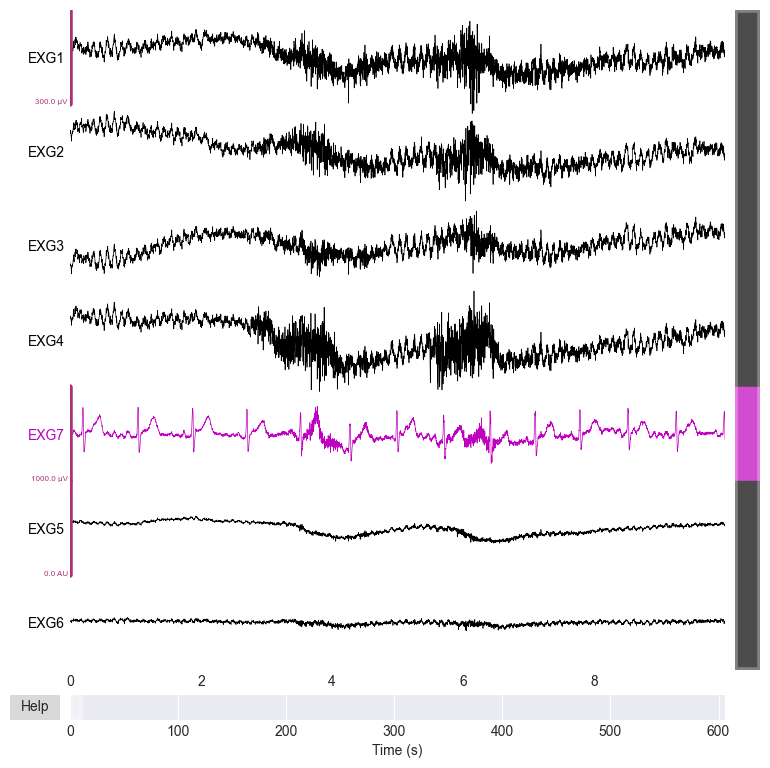

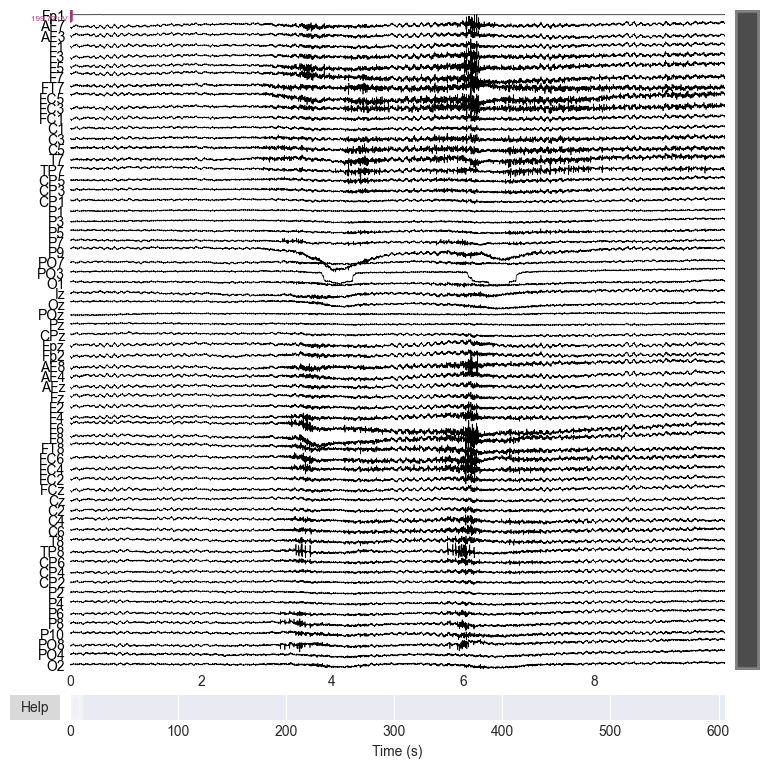

<Figure size 640x480 with 0 Axes>

Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


d:\Hackathons\EPFL_Life_Sciences_2026\EEG-Meditation-App\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
C:\Users\horvt\AppData\Local\Temp\ipykernel_7768\4123941940.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\horvt\AppData\Local\Temp\ipykernel_7768\4123941940.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


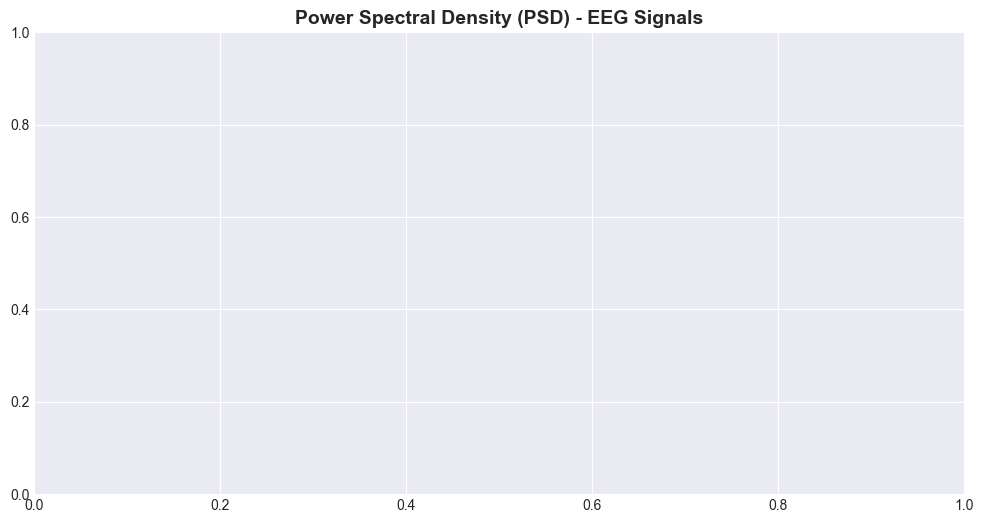

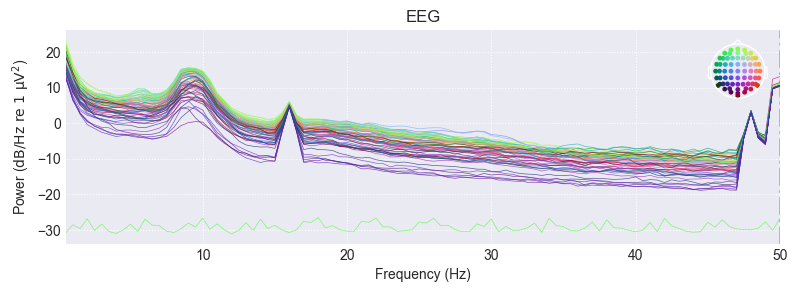

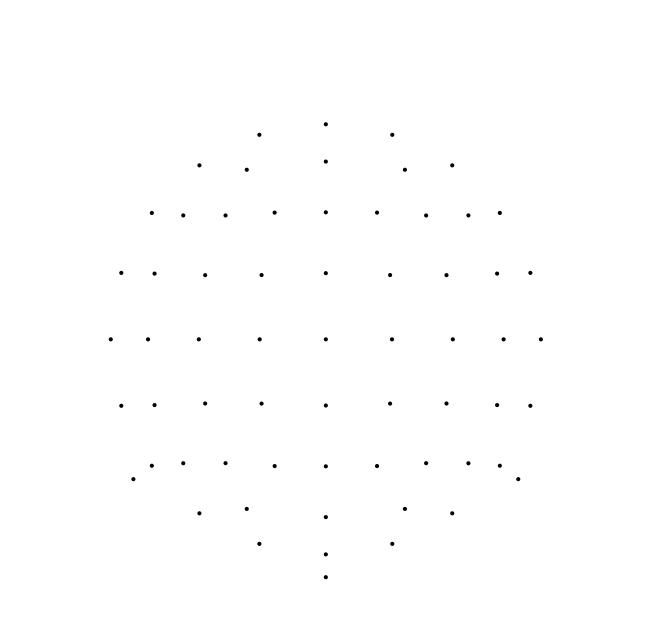

<Figure size 640x480 with 0 Axes>

In [27]:
# Visualize the first 10 seconds of EEG data
if raw is not None:
    print(raw.ch_names)

    #EXG 1 --> left eye corner
    #EXG 2 --> right eye corner
    #EXG 3 --> left eye eyebrow (above)
    #EXG 4 --> left eye below
    #EXG 7 --> middle of the collar bone
    #EXG 5 --> left mastoide
    #EXG 6 --> right mastoide

    eeg_signal = raw.copy().pick(mne.pick_types(raw.info, eeg=True, exclude='bads'))
    artifact_signal = raw.copy().pick(['EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7'])
    artifact_signal.plot()

    # Plot a portion of the data
    fig = eeg_signal.plot(duration=10, n_channels=64, scalings='auto')
    plt.suptitle('EEG Signals - First 10 Seconds', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Create a power spectral density plot
    fig, ax = plt.subplots(figsize=(12, 6))
    eeg_signal.compute_psd(fmin=0.5, fmax=50, n_jobs=1).plot()
    ax.set_title('Power Spectral Density (PSD) - EEG Signals', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Plot channel locations (if montage is available)
    try:
        fig = eeg_signal.plot_sensors()
        plt.suptitle('EEG Channel Locations', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot channel locations: {e}")
else:
    print("No raw data to visualize. Please load data from a BIDS file first.")

# Preprocessing

Using EOG channels: EXG1, EXG2, EXG3, EXG4
EOG channel index for this subject is: [64 65 66 67]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EXG3 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10240 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 798 significant peaks
Number of EOG events detected: 798
Not setting metadata
798 matching events found
No baseline correction applied
Loading data for 798 events and 1025 original time points ...
1 bad epochs dropped
Applying basel

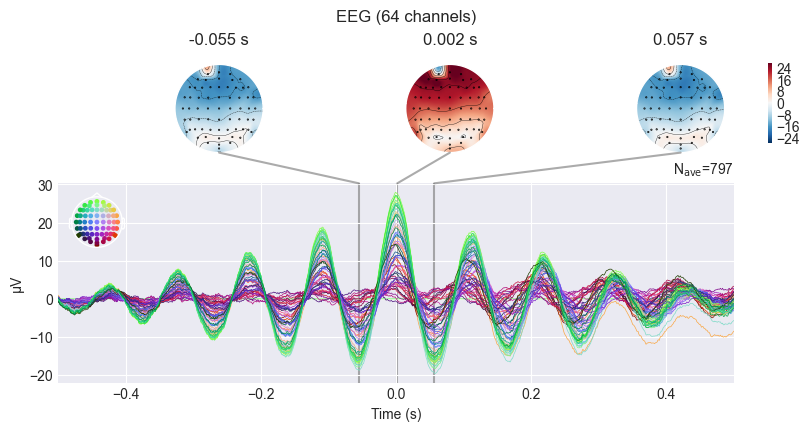

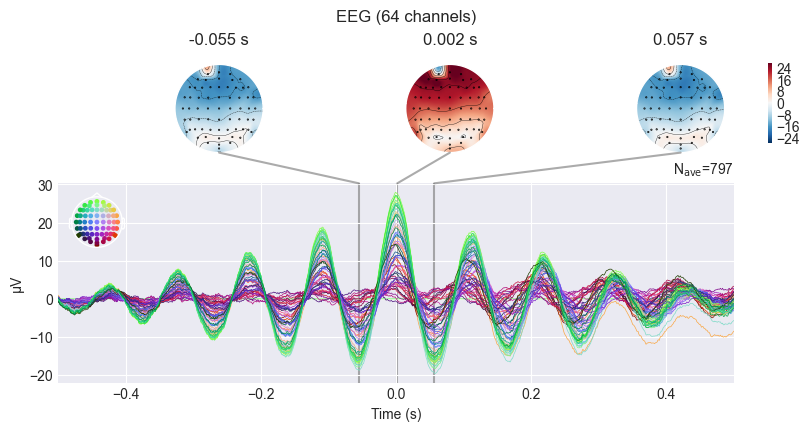

In [28]:
eog_evoked = mne.preprocessing.create_eog_epochs(raw).average()
eog_evoked.apply_baseline(baseline=(None, -0.2))
eog_evoked.plot_joint()

Using channel EXG7 to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 10240 samples (10.000 s)

Number of ECG events detected : 637 (average pulse 63.069306930693074 / min.)
Not setting metadata
637 matching events found
No baseline correction applied
Loading data for 637 events and 1025 original time points ...
1 bad epochs dropped
Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


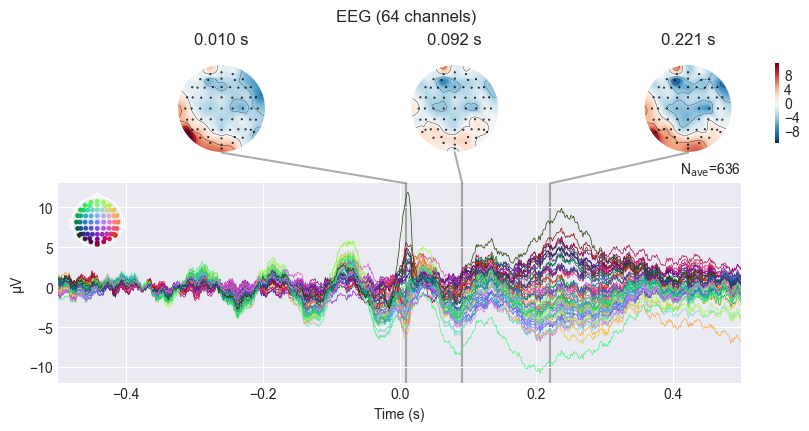

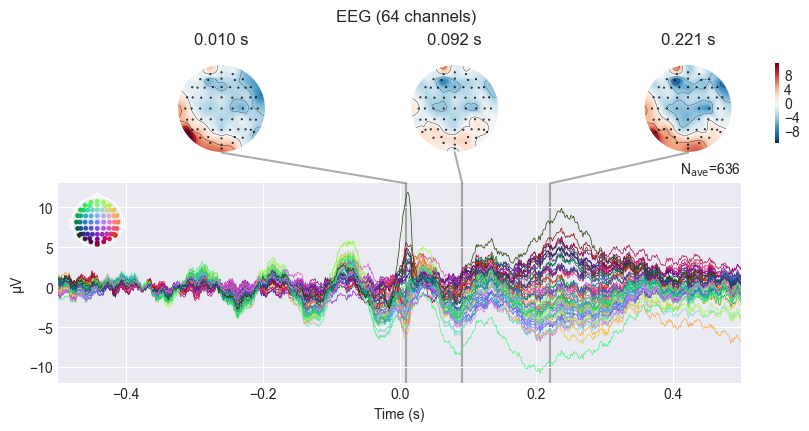

In [29]:
ecg_evoked = mne.preprocessing.create_ecg_epochs(raw).average()
ecg_evoked.apply_baseline(baseline=(None, -0.2))
ecg_evoked.plot_joint()

In [30]:
# ── 1. Prepare ──────────────────────────────────────────────────

raw.load_data()
filt_raw =raw.copy().filter(1, 40)                         # ICA needs high-pass ≥ 1 Hz

# ── 2. Fit ICA ──────────────────────────────────────────────────
ica = mne.preprocessing.ICA(
    n_components=20,    # start with 20; can go up to 64
    method='fastica',   # or 'infomax', 'picard'
    random_state=42
)
ica.fit(filt_raw)
ica

Reading 0 ... 620543  =      0.000 ...   605.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3381 samples (3.302 s)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 37.7s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,36 iterations on raw data (620544 samples)
ICA components,20
Available PCA components,64
Channel types,eeg
ICA components marked for exclusion,—


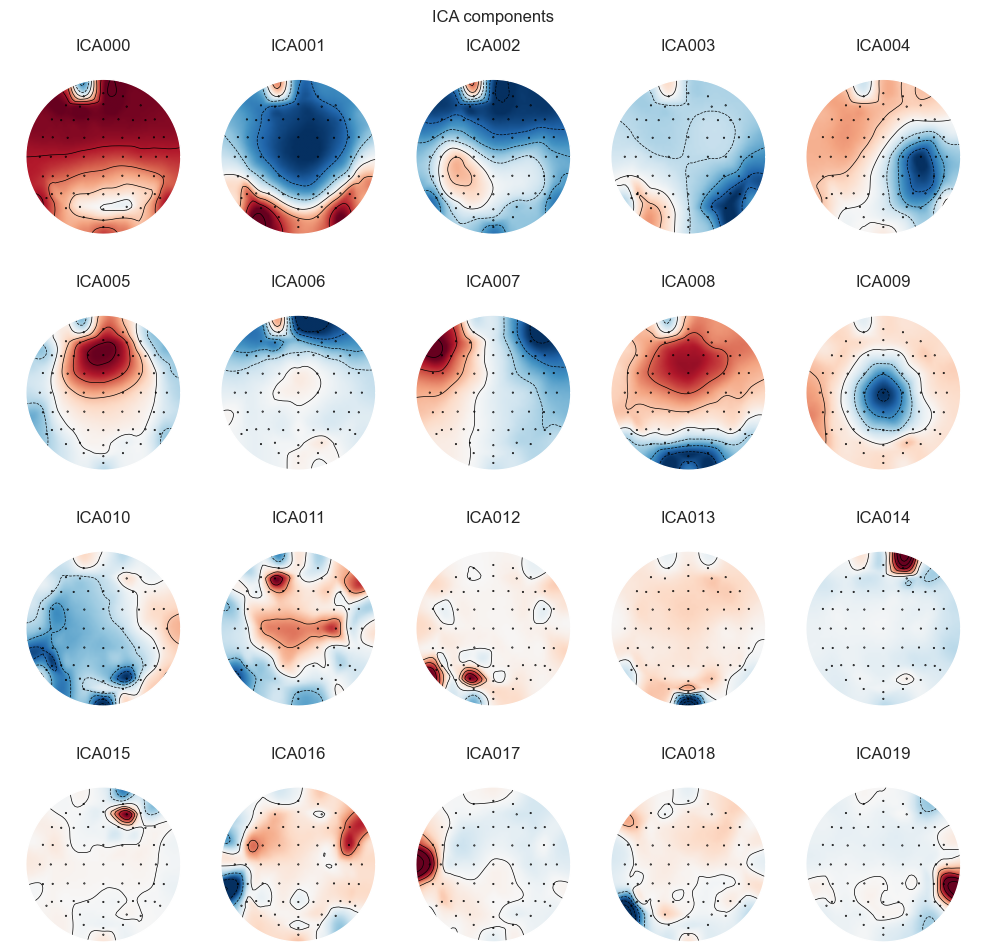

Creating RawArray with float64 data, n_channels=25, n_times=620544
    Range : 0 ... 620543 =      0.000 ...   605.999 secs
Ready.


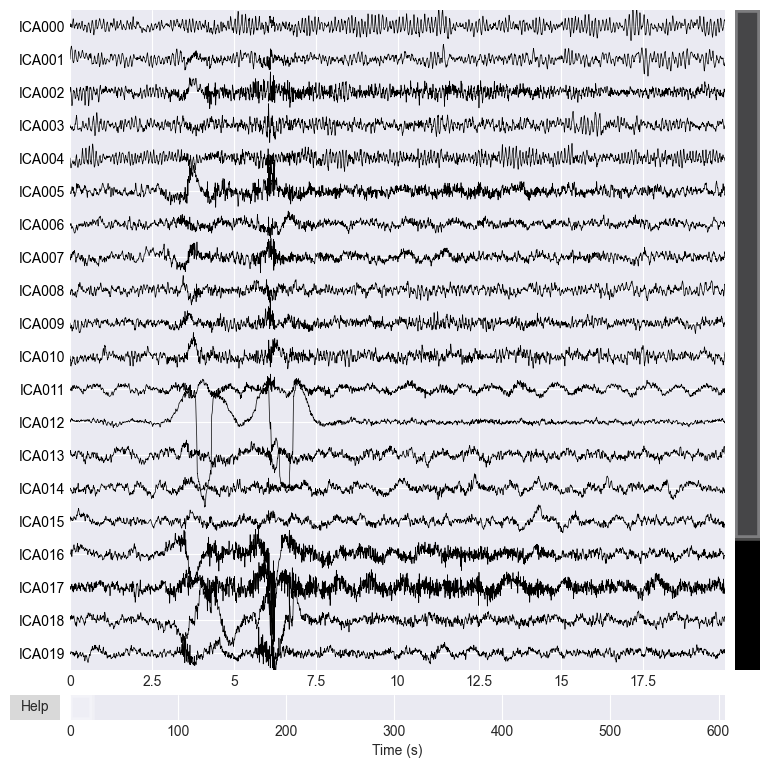

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
303 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
303 matching events found
No baseline correction applied
0 projection items activated


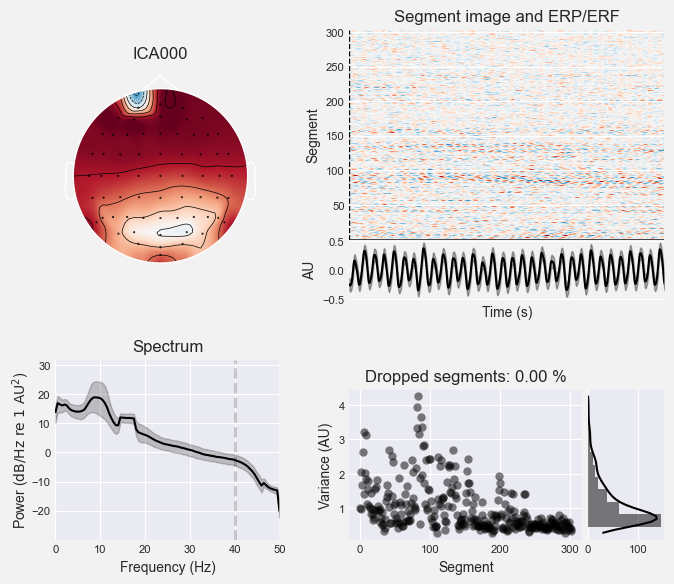

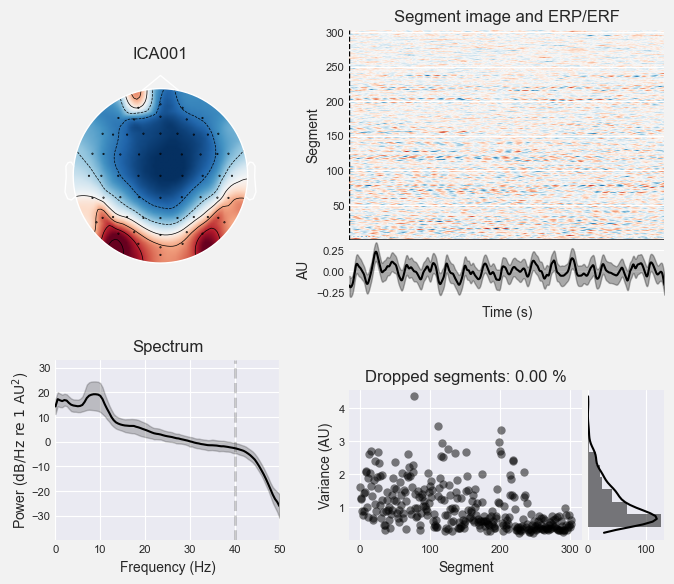

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 64 PCA components


<RawBDF | sub-001_task-med1breath_eeg.bdf, 80 x 620544 (606.0 s), ~378.8 MiB, data loaded>

In [13]:
# ── 3. Visualize components ─────────────────────────────────────
ica.plot_components()            # topomaps of all components
ica.plot_sources(filt_raw)        # time series — scroll to spot artifacts

# ── 4. Inspect suspects ─────────────────────────────────────────
ica.plot_properties(filt_raw, picks=[0, 1])  # detailed view of IC 0 and 1

# ── 5. Auto-detect EOG artifacts (if you have EOG in EXG channels)
# ica.find_bads_eog(filt_raw, ch_name='EXG1')

# ── 6. Exclude and apply ────────────────────────────────────────
ica.exclude = [0, 1]             # set after inspecting plots
ica.apply(filt_raw)

In [17]:
# After fitting ICA:
ic_labels = label_components(raw, ica, method="iclabel")
labels = ic_labels["labels"]  # e.g. ['brain', 'eye blink', 'muscle', ...]
probabilities = ic_labels["y_pred_proba"]

# Auto-reject non-brain components
exclude = [i for i, label in enumerate(labels) if label not in ("brain", "other")]
ica.exclude = exclude
ica.apply(raw)


C:\Users\horvt\AppData\Local\Temp\ipykernel_7768\2225509808.py:2: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method="iclabel")
C:\Users\horvt\AppData\Local\Temp\ipykernel_7768\2225509808.py:2: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method="iclabel")
C:\Users\horvt\AppData\Local\Temp\ipykernel_7768\2225509808.py:2: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended 

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 3 ICA components
    Projecting back using 64 PCA components


<RawBDF | sub-001_task-med1breath_eeg.bdf, 80 x 620544 (606.0 s), ~378.8 MiB, data loaded>

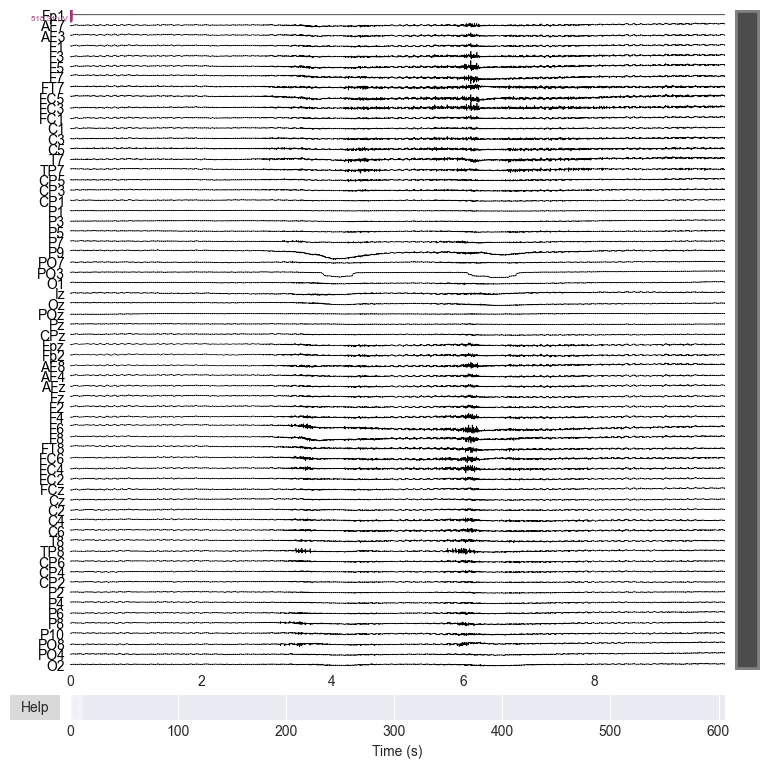

<Figure size 640x480 with 0 Axes>

In [18]:
eeg_signal = raw.copy().pick(mne.pick_types(raw.info, eeg=True, exclude='bads'))

# Plot a portion of the data
fig = eeg_signal.plot(duration=10, n_channels=64, scalings='auto')
plt.suptitle('EEG Signals - First 10 Seconds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()